In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn 
import tensorflow
import warnings
import time

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

In [2]:
tensorflow.__version__

'2.20.0'

In [3]:
start_time = time.time()

In [4]:
np.random.seed(42)
timesteps = 500
features = 3  # e.g., temp, humidity, wind

## Create Sync Data For the Model

In [5]:
data = np.sin(np.linspace(0, 50, timesteps)).reshape(-1,1) + np.random.randn(timesteps, features)*0.1
df = pd.DataFrame(data, columns=['temp', 'humidity', 'wind'])

In [6]:
df.head()

,temp,humidity,wind
0,0.049671,-0.013826,0.064769
1,0.252336,0.076617,0.076619
2,0.356983,0.275806,0.152115
3,0.350351,0.249753,0.249522
4,0.414353,0.198829,0.217665


In [7]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)  # shape (timesteps, features)

In [8]:
def create_multistep_sequences(data, window_size=24, forecast_horizon=5):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i+window_size])                     # past timesteps
        y.append(data[i+window_size:i+window_size+forecast_horizon])  # next N timesteps
    return np.array(X), np.array(y)

window_size = 24
forecast_horizon = 5

X, y = create_multistep_sequences(scaled_data, window_size, forecast_horizon)
print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)  # (samples, forecast_horizon, features)

X shape: (472, 24, 3)
y shape: (472, 5, 3)


## Split Data Set

In [9]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Build the LSTM model

In [10]:
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(window_size, features)))
model.add(RepeatVector(forecast_horizon))  # repeat output for each future timestep
model.add(LSTM(32, activation='tanh', return_sequences=True))
model.add(TimeDistributed(Dense(features)))  # predict all features at each timestep

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 5, 32)               │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 5, 3)                │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,923 (116.89 KB)

 Trainable params: 29,923 (116.89 KB)

 Non-trainable params: 0 (0.00 B)

## Traing the Model

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/100
19/19 - 3s - 157ms/step - loss: 0.1886 - val_loss: 0.0993
Epoch 2/100
19/19 - 0s - 13ms/step - loss: 0.0778 - val_loss: 0.0655
Epoch 3/100
19/19 - 0s - 13ms/step - loss: 0.0409 - val_loss: 0.0283
Epoch 4/100
19/19 - 0s - 13ms/step - loss: 0.0148 - val_loss: 0.0098
Epoch 5/100
19/19 - 0s - 13ms/step - loss: 0.0057 - val_loss: 0.0046
Epoch 6/100
19/19 - 0s - 12ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 7/100
19/19 - 0s - 13ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 8/100
19/19 - 0s - 12ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 9/100
19/19 - 0s - 12ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 10/100
19/19 - 0s - 12ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 11/100
19/19 - 0s - 13ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 12/100
19/19 - 0s - 13ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 13/100
19/19 - 0s - 12ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 14/100
19/19 - 0s - 12ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 15/100
19/19 - 0s - 12

## Make Predictions

In [12]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


In [13]:
# Reshape for inverse scaling
y_test_reshaped = y_test.reshape(-1, features)
y_pred_reshaped = y_pred.reshape(-1, features)

y_test_inv = scaler.inverse_transform(y_test_reshaped).reshape(-1, forecast_horizon, features)
y_pred_inv = scaler.inverse_transform(y_pred_reshaped).reshape(-1, forecast_horizon, features)


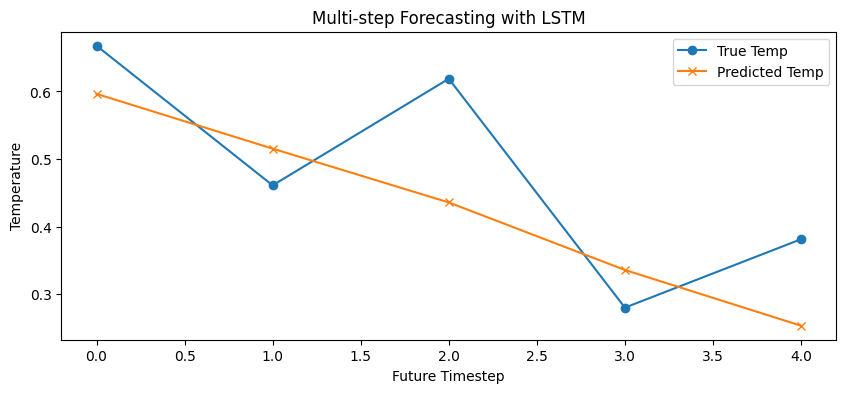

In [14]:
plt.figure(figsize=(10,4))
plt.plot(range(forecast_horizon), y_test_inv[0,:,0], marker='o', label='True Temp')
plt.plot(range(forecast_horizon), y_pred_inv[0,:,0], marker='x', label='Predicted Temp')
plt.xlabel("Future Timestep")
plt.ylabel("Temperature")
plt.title("Multi-step Forecasting with LSTM")
plt.legend()
plt.show()

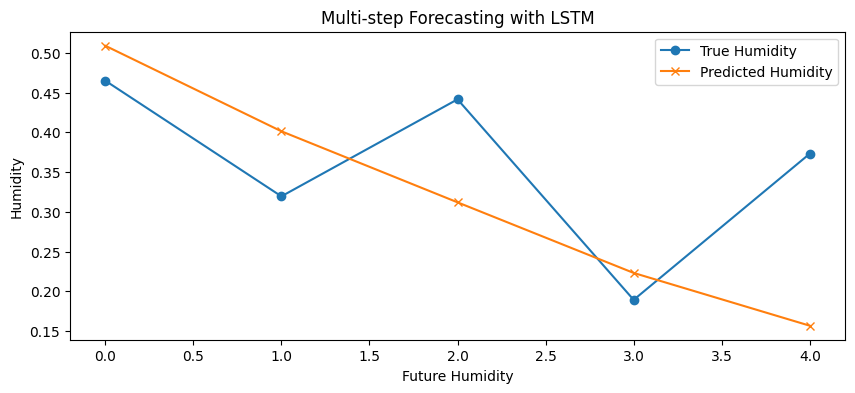

In [15]:
plt.figure(figsize=(10,4))
plt.plot(range(forecast_horizon), y_test_inv[1,:,1], marker='o', label='True Humidity')
plt.plot(range(forecast_horizon), y_pred_inv[1,:,1], marker='x', label='Predicted Humidity')
plt.xlabel("Future Humidity")
plt.ylabel("Humidity")
plt.title("Multi-step Forecasting with LSTM")
plt.legend()
plt.show()

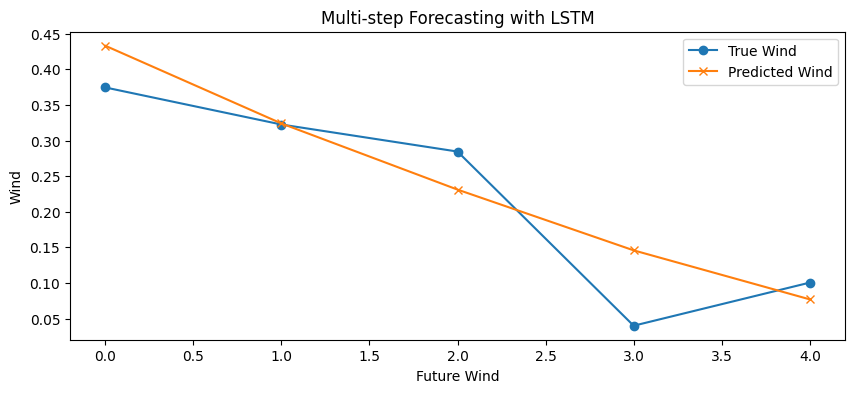

In [16]:
plt.figure(figsize=(10,4))
plt.plot(range(forecast_horizon), y_test_inv[2,:,2], marker='o', label='True Wind')
plt.plot(range(forecast_horizon), y_pred_inv[2,:,2], marker='x', label='Predicted Wind')
plt.xlabel("Future Wind")
plt.ylabel("Wind")
plt.title("Multi-step Forecasting with LSTM")
plt.legend()
plt.show()

In [17]:
end_time = time.time()
total_time = end_time - start_time
print(f"The total time to run this notebook was {total_time/60:.3f} minutes.")

The total time to run this notebook was 0.248 minutes.
